# Tennis Match Winner Prediction with CatBoost

## Goal

The task is a **binary classification problem**:

- class `1`: player A wins;
- class `0`: player B wins.

The objective is to train a CatBoost classifier and evaluate whether it can
generalize to matches played after those used for training.

## Why CatBoost?

CatBoost is an **ensemble method based on boosting**. As discussed for
AdaBoost, boosting combines several decision trees sequentially: every new
tree tries to reduce the errors made by the current ensemble.

The final prediction is obtained by combining the contribution of all trees.
CatBoost is useful here because the dataset contains both numerical and
categorical attributes, such as surface, court and tournament.

## Setup

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    brier_score_loss,
    classification_report,
    log_loss,
    roc_auc_score,
)

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS_DIR = PROJECT_ROOT / "scripts" / "models"
sys.path.insert(0, str(MODELS_DIR))

from train_catboost import chronological_split, prepare_catboost_features  # noqa: E402

FEATURES_PATH = PROJECT_ROOT / "data/interim/tennis_matches_features.data"
METADATA_PATH = PROJECT_ROOT / "data/interim/tennis_matches_features_metadata.json"
METRICS_PATH = PROJECT_ROOT / "data/interim/catboost_metrics.json"
MODEL_PATH = PROJECT_ROOT / "data/interim/catboost_model.cbm"

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Load the dataset

In [2]:
dataset = pd.read_csv(FEATURES_PATH)
dataset["date"] = pd.to_datetime(dataset["date"], errors="raise")

metadata = json.loads(METADATA_PATH.read_text(encoding="utf-8"))
training_metrics = json.loads(METRICS_PATH.read_text(encoding="utf-8"))

columns_to_show = [
    "date",
    "surface",
    "winner_rank",
    "loser_rank",
    "rank_diff",
    "win_rate_diff",
    "implied_prob_diff_avg",
    "player_a_win",
]

print("Dataset shape:", dataset.shape)
display(dataset[columns_to_show].head())
display(dataset["player_a_win"].value_counts().sort_index().rename("instances").to_frame())

Dataset shape: (30952, 115)


,date,surface,winner_rank,loser_rank,rank_diff,win_rate_diff,implied_prob_diff_avg,player_a_win
0,2020-01-06,Hard,76.0,58.0,-18.0,NaN,-0.013926,0
1,2020-01-06,Hard,58.0,76.0,18.0,NaN,0.013926,1
2,2020-01-06,Hard,43.0,55.0,12.0,NaN,0.107462,0
3,2020-01-06,Hard,55.0,43.0,-12.0,NaN,-0.107462,1
4,2020-01-06,Hard,83.0,54.0,-29.0,NaN,-0.248736,0


,instances
player_a_win,
0,15476
1,15476


The dataset contains two rows for every real match: one for each
player orientation. This produces a balanced target and avoids making the
model depend on the original winner/loser column order.

Only pre-match information is used: rankings, previous results, surface form,
head-to-head history, player statistics and market probabilities.

## 2. Prepare features and create the train/test split

A random split is not appropriate for this problem because it could
train the model on future matches and test it on older matches.

The most recent 15% of unique dates is therefore used as the **test set**. The
remaining older matches form the **training set**. Both orientations of a
match have the same date and remain in the same partition.

In [3]:
numeric_features = tuple(metadata["numeric_features"])
categorical_features = tuple(metadata["categorical_features"])
feature_names = numeric_features + categorical_features

X = prepare_catboost_features(
    dataset.loc[:, feature_names],
    numeric_features,
    categorical_features,
)
y = dataset["player_a_win"].astype(int)

train_mask, test_mask = chronological_split(dataset)
train_index = np.flatnonzero(train_mask)
test_index = np.flatnonzero(test_mask)
X_train, X_test = X.iloc[train_index], X.iloc[test_index]
y_train, y_test = y.iloc[train_index], y.iloc[test_index]

split = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_test)],
        "first date": [
            dataset.iloc[train_index]["date"].min().date(),
            dataset.iloc[test_index]["date"].min().date(),
        ],
        "last date": [
            dataset.iloc[train_index]["date"].max().date(),
            dataset.iloc[test_index]["date"].max().date(),
        ],
    },
    index=["training", "test"],
)
display(split)

,rows,first date,last date
training,26472,2020-01-06,2025-08-07
test,4480,2025-08-08,2026-07-12


## 3. Naive baseline

A classifier must be compared with a simple baseline. Following the
course notes, the naive classifier always predicts the majority class.

Because the symmetric dataset is balanced, the expected baseline accuracy is
approximately 50%.

In [4]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_accuracy = accuracy_score(y_test, baseline.predict(X_test))

print(f"Naive baseline accuracy: {baseline_accuracy:.4f}")

Naive baseline accuracy: 0.5000


## 4. Fixed model parameters

The current trainer uses fixed parameters: 300 trees, depth 8,
learning rate 0.03 and L2 leaf regularization 3, with random seed 42.
This run performs no cross-validation, parameter search or early stopping.

In [5]:
model = CatBoostClassifier()
model.load_model(str(MODEL_PATH))
display(pd.Series(model.get_params(), name="parameters").to_frame())

,parameters
allow_writing_files,False
verbose,0
iterations,300
loss_function,Logloss
l2_leaf_reg,3
depth,8
random_seed,42
learning_rate,0.03


## 5. Load the trained model

Run `python scripts/models/train_catboost.py` from the project root
before executing this notebook. The trainer calls `model.fit(X_train, y_train)`
and saves the model. This notebook evaluates that saved model so its results
can be checked directly against the training metrics.

## 6. Evaluate the classifier

In [6]:
train_prediction = model.predict(X_train).astype(int).ravel()
test_probability = model.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= 0.5).astype(int)

train_accuracy = accuracy_score(y_train, train_prediction)
test_accuracy = accuracy_score(y_test, test_prediction)
test_auc = roc_auc_score(y_test, test_probability)
test_log_loss = log_loss(y_test, test_probability)
test_brier_score = brier_score_loss(y_test, test_probability)
assert np.isclose(test_accuracy, training_metrics["holdout_accuracy"])
assert np.isclose(test_auc, training_metrics["holdout_roc_auc"])
market_probability = dataset.iloc[test_index]["winner_market_prob_normalized"]
market_valid = market_probability.notna()
market_y = y_test.loc[market_valid]
market_probability = market_probability.loc[market_valid]
market_metrics = {
    "accuracy": accuracy_score(market_y, market_probability >= 0.5),
    "roc_auc": roc_auc_score(market_y, market_probability),
    "log_loss": log_loss(market_y, market_probability),
    "brier_score": brier_score_loss(market_y, market_probability),
}
print(f"Market baseline coverage: {market_valid.mean():.1%}")
results = pd.DataFrame(
    {
        "Accuracy": [baseline_accuracy, test_accuracy, market_metrics["accuracy"]],
        "ROC AUC": [np.nan, test_auc, market_metrics["roc_auc"]],
        "Log loss": [np.nan, test_log_loss, market_metrics["log_loss"]],
        "Brier score": [np.nan, test_brier_score, market_metrics["brier_score"]],
    },
    index=["Naive baseline", "CatBoost holdout", "Market baseline"],
)
display(results)
print(f"Training accuracy: {train_accuracy:.4f}")
print("Saved model metrics verified.")

Market baseline coverage: 100.0%


,Accuracy,ROC AUC,Log loss,Brier score
Naive baseline,0.500000,NaN,NaN,NaN
CatBoost holdout,0.694643,0.755905,0.583378,0.200344
Market baseline,0.691518,0.757795,0.581768,0.199607


Training accuracy: 0.7062
Saved model metrics verified.


### Confusion matrix

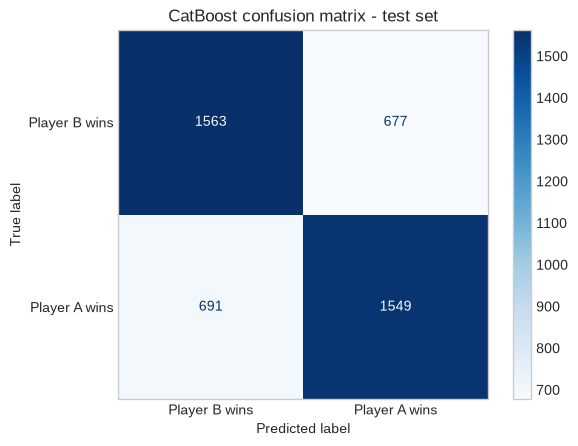

In [7]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_prediction,
    display_labels=["Player B wins", "Player A wins"],
    cmap="Blues",
)
plt.title("CatBoost confusion matrix - test set")
plt.grid(False)
plt.show()

### Precision, recall and F1-score

In [8]:
print(
    classification_report(
        y_test,
        test_prediction,
        target_names=["Player B wins", "Player A wins"],
        digits=4,
    )
)

               precision    recall  f1-score   support

Player B wins     0.6934    0.6978    0.6956      2240
Player A wins     0.6959    0.6915    0.6937      2240

     accuracy                         0.6946      4480
    macro avg     0.6947    0.6946    0.6946      4480
 weighted avg     0.6947    0.6946    0.6946      4480



### ROC curve

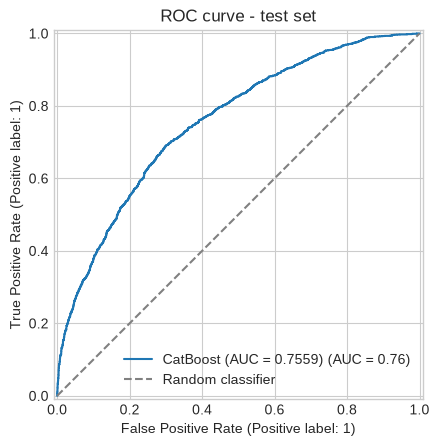

In [9]:
RocCurveDisplay.from_predictions(
    y_test,
    test_probability,
    name=f"CatBoost (AUC = {test_auc:.4f})",
)
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random classifier")
plt.title("ROC curve - test set")
plt.legend()
plt.show()

## 7. Feature importance

Tree-based models expose a feature-importance score. The score
indicates how much each feature contributes to the decisions of the ensemble.
As discussed in the course, importance is useful for interpretation, but it
does not prove that a feature causes the prediction.

,importance
implied_prob_diff_avg,6.874215
normalized_market_prob_diff,6.813603
winner_market_prob_normalized,6.214114
loser_market_prob_normalized,5.677338
loser_implied_prob_avg,5.610938
winner_implied_prob_avg,4.776706
market_overround_avg,3.279031
smoothed_surface_diff,2.150686
surface_win_rate_diff,1.868515
log_points_diff,1.865743


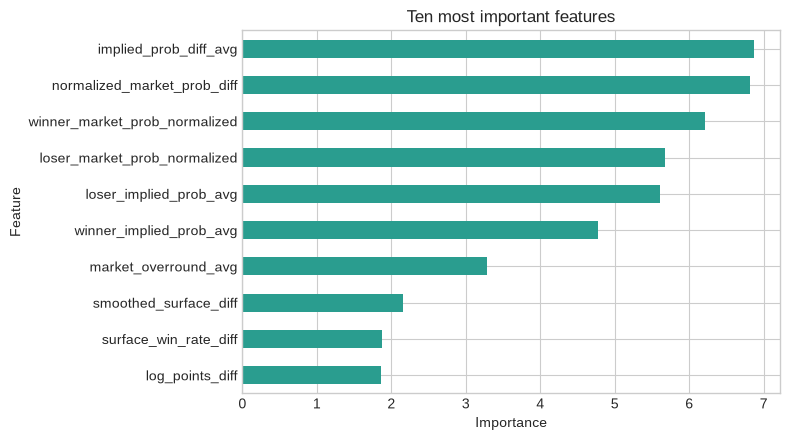

In [10]:
feature_importance = (
    pd.Series(
        model.get_feature_importance(
            Pool(X_train, y_train, cat_features=categorical_features)
        ),
        index=feature_names,
        name="importance",
    )
    .sort_values(ascending=False)
)

assert np.isfinite(feature_importance).all()
assert feature_importance.sum() > 0
display(feature_importance.head(10).to_frame())

ax = feature_importance.head(10).sort_values().plot(
    kind="barh",
    figsize=(8, 4.5),
    color="#2a9d8f",
)
ax.set_title("Ten most important features")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

## 8. Inspect the easiest and hardest matches

Rows are paired by `match_id_internal`, so every real match is
counted once for this diagnostic only; the main metrics above evaluate raw
row predictions, as in the trainer. Confidence in the real winner is averaged across the two player
orientations. The most correct matches have the highest probability assigned
to the actual winner; the most wrong matches have the lowest.

In [11]:
holdout = dataset.iloc[test_index].copy()
holdout["actual_winner_probability"] = np.where(
    y_test.eq(1), test_probability, 1 - test_probability
)
holdout["actual_winner_probability"] = holdout.groupby("match_id_internal")[
    "actual_winner_probability"
].transform("mean")

pair_sizes = holdout.groupby("match_id_internal").size()
assert pair_sizes.eq(2).all(), "Each holdout match must have two orientations."

match_diagnostics = (
    holdout.loc[holdout["player_a_win"].eq(1)]
    .set_index("match_id_internal")
)
match_diagnostics["correct"] = (
    match_diagnostics["actual_winner_probability"] >= 0.5
)
match_diagnostics["predicted_winner"] = np.where(
    match_diagnostics["correct"],
    match_diagnostics["winner_name"],
    match_diagnostics["loser_name"],
)

assert len(match_diagnostics) * 2 == len(holdout)
print(f"Real holdout matches: {len(match_diagnostics):,}")
print(f"Match-level accuracy: {match_diagnostics['correct'].mean():.4f}")

Real holdout matches: 2,240
Match-level accuracy: 0.6915


### Most confident correct predictions

In [12]:
instance_columns = [
    "date",
    "winner_name",
    "loser_name",
    "predicted_winner",
    "surface",
    "round",
    "series",
    "winner_rank",
    "loser_rank",
    "normalized_market_prob_diff",
    "actual_winner_probability",
]

most_correct = match_diagnostics.nlargest(
    10, "actual_winner_probability"
)[instance_columns]
display(most_correct)

,date,winner_name,loser_name,predicted_winner,surface,round,series,winner_rank,loser_rank,normalized_market_prob_diff,actual_winner_probability
match_id_internal,,,,,,,,,,,
14041,2026-01-18,Alcaraz C.,Walton A.,Alcaraz C.,Hard,1st Round,GrandSlam,1.0,81.0,0.919426,0.963007
13534,2025-09-25,Alcaraz C.,Baez S.,Alcaraz C.,Hard,1st Round,ATP500,1.0,41.0,0.893008,0.956461
13887,2025-11-04,Hanfmann Y.,Ivanov I.,Hanfmann Y.,Hard,1st Round,ATP250,117.0,935.0,0.819728,0.956392
14128,2026-01-22,Sinner J.,Duckworth J.,Sinner J.,Hard,2nd Round,GrandSlam,2.0,88.0,0.912781,0.954296
13679,2025-10-13,Diallo G.,Omarkhanov A.,Diallo G.,Hard,1st Round,ATP250,35.0,1137.0,0.880841,0.954202
14868,2026-04-24,Sinner J.,Bonzi B.,Sinner J.,Clay,2nd Round,Masters1000,1.0,104.0,0.922842,0.952056
15375,2026-06-29,Sinner J.,Kecmanovic M.,Sinner J.,Grass,1st Round,GrandSlam,1.0,50.0,0.897306,0.950985
13433,2025-08-28,Alcaraz C.,Bellucci M.,Alcaraz C.,Hard,2nd Round,GrandSlam,2.0,65.0,0.871698,0.950577
13476,2025-09-06,Sinner J.,Auger-Aliassime F.,Sinner J.,Hard,Semifinals,GrandSlam,1.0,27.0,0.857044,0.950257


### Most confident wrong predictions

In [13]:
most_wrong = match_diagnostics.nsmallest(
    10, "actual_winner_probability"
)[instance_columns]
display(most_wrong)

,date,winner_name,loser_name,predicted_winner,surface,round,series,winner_rank,loser_rank,normalized_market_prob_diff,actual_winner_probability
match_id_internal,,,,,,,,,,,
15145,2026-05-28,Cerundolo J.M.,Sinner J.,Sinner J.,Clay,2nd Round,GrandSlam,56.0,1.0,-0.917585,0.051573
13833,2025-10-28,Norrie C.,Alcaraz C.,Alcaraz C.,Hard,2nd Round,Masters1000,31.0,1.0,-0.818809,0.053041
14635,2026-03-30,Bennani K.,Halys Q.,Halys Q.,Clay,1st Round,ATP250,731.0,90.0,-0.805014,0.064482
14634,2026-03-30,Baadi T.,Vukic A.,Vukic A.,Clay,1st Round,ATP250,587.0,84.0,-0.768398,0.069704
14159,2026-01-30,Djokovic N.,Sinner J.,Sinner J.,Hard,Semifinals,GrandSlam,4.0,2.0,-0.779381,0.082165
14382,2026-02-24,Kypson P.,De Minaur A.,De Minaur A.,Hard,1st Round,ATP500,103.0,6.0,-0.785208,0.090184
15126,2026-05-26,Walton A.,Medvedev D.,Medvedev D.,Clay,1st Round,GrandSlam,97.0,8.0,-0.845577,0.093540
13900,2025-11-05,Sachko V.,Bublik A.,Bublik A.,Hard,2nd Round,ATP250,222.0,13.0,-0.692308,0.103368
15169,2026-05-30,Svajda Z.,Cerundolo F.,Cerundolo F.,Clay,3rd Round,GrandSlam,85.0,26.0,-0.756818,0.120437


### Numeric feature distributions: correct vs wrong

For each numeric feature, the table compares cohort medians,
missing-value rates and the mean shift measured in overall standard deviations.
Large absolute shifts identify where wrong predictions occupy a different part
of the feature distribution; they do not establish causality.

,feature,wrong_minus_correct_sd,correct_median,wrong_median,correct_missing_rate,wrong_missing_rate,absolute_shift,missing_rate_delta
15,winner_implied_prob_avg,-1.736954,0.719424,0.404858,0.000000,0.000000,1.736954,0.000000
17,implied_prob_diff_avg,-1.734232,0.378128,-0.250369,0.000000,0.000000,1.734232,0.000000
16,loser_implied_prob_avg,1.731205,0.341297,0.653595,0.000000,0.000000,1.731205,0.000000
39,normalized_market_prob_diff,-1.731102,0.355140,-0.236908,0.000000,0.000000,1.731102,0.000000
38,loser_market_prob_normalized,1.731102,0.322430,0.618454,0.000000,0.000000,1.731102,0.000000
37,winner_market_prob_normalized,-1.731102,0.677570,0.381546,0.000000,0.000000,1.731102,0.000000
68,elo_diff,-1.261641,122.614179,-77.901166,0.000000,0.000000,1.261641,0.000000
41,log_rank_diff,-1.203744,0.980829,-0.550046,0.000646,0.002894,1.203744,0.002249
71,surface_elo_diff,-1.186986,96.580179,-59.014933,0.000000,0.000000,1.186986,0.000000
43,log_points_diff,-1.174737,0.798589,-0.414978,0.000646,0.002894,1.174737,0.002249


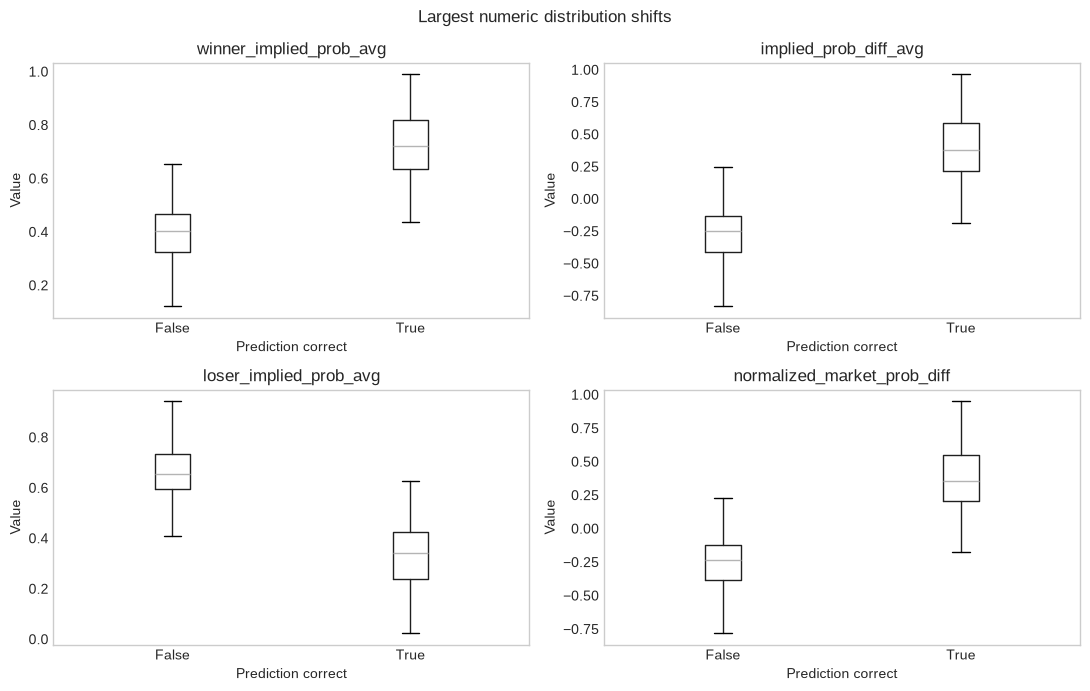

In [14]:
distribution_rows = []
for feature in numeric_features:
    correct_values = pd.to_numeric(
        match_diagnostics.loc[match_diagnostics["correct"], feature],
        errors="coerce",
    )
    wrong_values = pd.to_numeric(
        match_diagnostics.loc[~match_diagnostics["correct"], feature],
        errors="coerce",
    )
    overall_std = pd.to_numeric(
        match_diagnostics[feature], errors="coerce"
    ).std()
    standardized_shift = (
        (wrong_values.mean() - correct_values.mean()) / overall_std
        if overall_std > 0
        else np.nan
    )
    distribution_rows.append(
        {
            "feature": feature,
            "wrong_minus_correct_sd": standardized_shift,
            "correct_median": correct_values.median(),
            "wrong_median": wrong_values.median(),
            "correct_missing_rate": correct_values.isna().mean(),
            "wrong_missing_rate": wrong_values.isna().mean(),
        }
    )

numeric_distribution_shift = (
    pd.DataFrame(distribution_rows)
    .assign(
        absolute_shift=lambda frame: frame["wrong_minus_correct_sd"].abs(),
        missing_rate_delta=lambda frame: (
            frame["wrong_missing_rate"] - frame["correct_missing_rate"]
        ),
    )
    .sort_values("absolute_shift", ascending=False)
)
display(numeric_distribution_shift.head(15))

top_shift_features = numeric_distribution_shift.head(4)["feature"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for feature, axis in zip(top_shift_features, axes.ravel(), strict=True):
    match_diagnostics.boxplot(
        column=feature,
        by="correct",
        ax=axis,
        showfliers=False,
        grid=False,
    )
    axis.set_title(feature)
    axis.set_xlabel("Prediction correct")
    axis.set_ylabel("Value")
plt.suptitle("Largest numeric distribution shifts")
plt.tight_layout()
plt.show()

### Categorical feature distributions

In [15]:
overall_error_rate = 1 - match_diagnostics["correct"].mean()
categorical_rows = []
for feature in categorical_features:
    grouped = match_diagnostics.groupby(feature, dropna=False)["correct"].agg(
        matches="size",
        error_rate=lambda values: 1 - values.mean(),
    )
    grouped = grouped.loc[grouped["matches"] >= 20].reset_index()
    grouped.insert(0, "feature", feature)
    categorical_rows.append(grouped.rename(columns={feature: "value"}))

categorical_error_rates = pd.concat(categorical_rows, ignore_index=True)
categorical_error_rates["difference_from_overall"] = (
    categorical_error_rates["error_rate"] - overall_error_rate
)
categorical_error_rates["absolute_difference"] = categorical_error_rates[
    "difference_from_overall"
].abs()
categorical_error_rates = categorical_error_rates.sort_values(
    "absolute_difference", ascending=False
)
display(categorical_error_rates.head(15))

,feature,value,matches,error_rate,difference_from_overall,absolute_difference
24,tournament_bucket,Dallas Open,31,0.129032,-0.179450,0.179450
75,location_bucket,Dallas,31,0.129032,-0.179450,0.179450
90,location_bucket,Marrakech,25,0.480000,0.171518,0.171518
31,tournament_bucket,Grand Prix Hassan II,25,0.480000,0.171518,0.171518
21,tournament_bucket,Chengdu Open,26,0.461538,0.153056,0.153056
45,tournament_bucket,Open de Moselle,26,0.461538,0.153056,0.153056
73,location_bucket,Chengdu,26,0.461538,0.153056,0.153056
92,location_bucket,Metz,26,0.461538,0.153056,0.153056
60,location_bucket,'s-Hertogenbosch,27,0.444444,0.135962,0.135962
49,tournament_bucket,Rosmalen Grass Court Championships,27,0.444444,0.135962,0.135962


### What is peculiar?

In [16]:
odds_importance_share = feature_importance.loc[
    [
        "winner_implied_prob_avg",
        "loser_implied_prob_avg",
        "implied_prob_diff_avg",
        "winner_market_prob_normalized",
        "loser_market_prob_normalized",
        "normalized_market_prob_diff",
    ]
].sum() / feature_importance.sum()
wrong_matches = match_diagnostics.loc[~match_diagnostics["correct"]]
upset_share = wrong_matches["normalized_market_prob_diff"].lt(0).mean()
largest_missing_gap = numeric_distribution_shift["missing_rate_delta"].abs().max()

print(f"Importance assigned to six odds features: {odds_importance_share:.1%}")
print(f"Wrong predictions where the actual winner was the market underdog: {upset_share:.1%}")
print(f"Largest correct/wrong missing-rate gap: {largest_missing_gap:.1%}")
print(
    "Interpretation: errors are mostly genuine upsets. Ranking, Elo, form and "
    "market-probability differences reverse direction in the wrong cohort. "
    "No comparably large missing-data anomaly is visible. Category-level "
    "differences should be treated cautiously because many groups are small."
)

Importance assigned to six odds features: 36.0%
Wrong predictions where the actual winner was the market underdog: 94.5%
Largest correct/wrong missing-rate gap: 4.2%
Interpretation: errors are mostly genuine upsets. Ranking, Elo, form and market-probability differences reverse direction in the wrong cohort. No comparably large missing-data anomaly is visible. Category-level differences should be treated cautiously because many groups are small.


## Conclusion

- The naive baseline obtains about **50% accuracy** because the classes are
  balanced.
- CatBoost obtains **0.6946** holdout accuracy with fixed parameters.
- The model improves clearly over the naive baseline.
- Market-implied probabilities are the most important features. Therefore,
  part of the predictive power comes from information already contained in
  betting odds.
- The most confident mistakes are mainly upsets in which rankings, Elo, form
  and betting odds all favored the eventual loser. There is no similarly large
  missing-value anomaly separating correct and wrong predictions.
- The difference between training and test accuracy should be monitored: a
  much larger training score would indicate over-fitting.

This is a rerun on an existing holdout, not a new independent test. Any future change to the
features or CatBoost parameters must be selected using the training
cross-validation folds, not this test result.